In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from unsilence import Unsilence
import librosa
from scipy.io import wavfile
from tqdm import tqdm


path_dir = "/Volumes/DISQUE_Tit/PROJECTS/Coughvid-COVID-Predictor/"
my_cough = "my_cough.wav"

counter=0
u = Unsilence(path_dir + my_cough )
u.detect_silence(short_interval_threshold=0.5)
audio, sample_rate = librosa.load(path_dir + my_cough)
for instant in u.get_intervals().serialize():
    #Only keep non-silent part
    if not instant['is_silent']:
        #Crop from start to end
        cropped_audio = audio[int(instant['start']*sample_rate//1-1) :int(instant['end']*sample_rate//1 +1)  ]
        wavfile.write(path_dir + "cropped_my_cough.wav", sample_rate, cropped_audio)

In [ ]:
from PIL import Image

mean_signal_length = 28835

Y = pd.DataFrame(columns=["uuid","cut_audio", "cut_melspec", "status"])


path_dir = "/Volumes/DISQUE_Tit/PROJECTS/Coughvid-COVID-Predictor/"
mels_path = "/Volumes/DISQUE_Tit/PROJECTS/Coughvid-COVID-Predictor/melspecs_mycough.png"

signal, sr = librosa.load(path_dir + "cropped_my_cough.wav")
s_len = len(signal)
if s_len < mean_signal_length:
    pad_len = mean_signal_length - s_len
    pad_rem = pad_len % 2
    pad_len //= 2
    signal = np.pad(
        signal, (pad_len, pad_len + pad_rem), "constant", constant_values=0
    )
else:
    pad_len = s_len - mean_signal_length
    pad_len //= 2
    signal = signal[pad_len : pad_len + mean_signal_length]
mel_spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128,
    hop_length=512,
    fmax=8000,
    n_fft=512,
    center=True,
)
dbscale_mel_spectrogram = librosa.power_to_db(
    mel_spectrogram, ref=np.max, top_db=80
)
plt.figure(figsize=(5.15, 1.99), dpi=100)  # Dimensions: 515 x 199
plt.imshow(dbscale_mel_spectrogram, interpolation='nearest', origin='lower', aspect='auto')
plt.axis('off')
plt.savefig(mels_path, dpi=100)
plt.close()
img = Image.open(mels_path).convert("RGB")
img.save(mels_path)


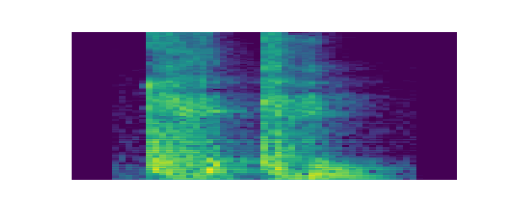

Input shape: (199, 515, 3)


In [8]:
im = plt.imread(mels_path)
plt.imshow(im)
plt.axis('off')
plt.show()

input_dim = im.shape  # (C, H, W)
print("Input shape:", input_dim)

In [ ]:
import os
import cv2
from torch.utils.data import Dataset

class MelSpectrogramDataset(Dataset):
    def __init__(self, img_dir,label):
        self.img_dir = img_dir
        self.label = label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        # Read image
        img_path = os.path.join(self.img_dir)
        img = cv2.imread(img_path)
        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)  # Convert (H, W, C) to (C, H, W)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(self.label, dtype=torch.float32)

cough_mel = MelSpectrogramDataset(
    img_dir=mels_path,
    label=0  # Assuming 0 for negative class (healty)
)

sample_img, _ = cough_mel[0]  # First image and label
input_dim = sample_img.shape  # (C, H, W)
print("Input shape:", input_dim)

Input shape: torch.Size([3, 199, 515])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from Models.CNN_LSTM_attention import CNN_LSTM_attention
from collections import OrderedDict

model = CNN_LSTM_attention(input_dim)

# Model was trained with DataParallel
state_dict = torch.load(
        '/Users/titouan/Desktop/Coughvid-COVID-Predictor/results_CNN_LSTM_attention/best_cnn_lstm_attention.pth',
    map_location=torch.device('cpu')
)

new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")  # remove 'module.' prefix
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict, strict=True)
model.eval()  # important for inference (disables dropout, etc.)

In [20]:
input_tensor, _ = cough_mel[0]  # ignore label if not needed
input_tensor = input_tensor.unsqueeze(0)  # add batch dimension
with torch.no_grad():
    output = model(input_tensor)
    print("Model output:", output)
    y_pred_proba = torch.sigmoid(output)
    print("Model proba:", y_pred_proba)
    label_predicted = (y_pred_proba >= 0.5).int()
    print("Model prediction:", label_predicted)

Model output: tensor([[-1.2101]])
Model proba: tensor([[0.2297]])
Model prediction: tensor([[0]], dtype=torch.int32)
